In [1]:
import pandas as pd
import geopandas as gpd
import numpy
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/Users/danalapides/opt/miniconda3/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in la

AttributeError: _ARRAY_API not found

Retrieving: daily · 1 page · 3,834 rows


<Axes: xlabel='time'>

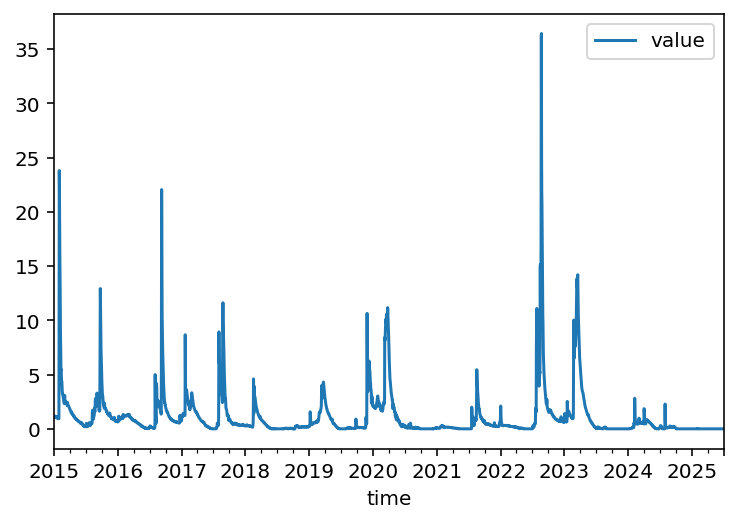

In [13]:
# Define the USGS gage site ID (e.g., '01438500' for Delaware River)
import dataretrieval.waterdata as wd
site_id = 'USGS-09470750'

# Fetch daily streamflow data for a specific date range
# The 'time' parameter uses an ISO 8601 interval string (start/end)
df, metadata = wd.get_daily(
    monitoring_location_id=site_id,
    parameter_code='00060',
    time='2015-01-01/2025-06-30'
)
df = df[['time','value']]
df['value'] = df['value']*12**3*2.54**3*10**3/10644850
df.set_index('time',inplace=True)
df.plot()

Ramsey 1160


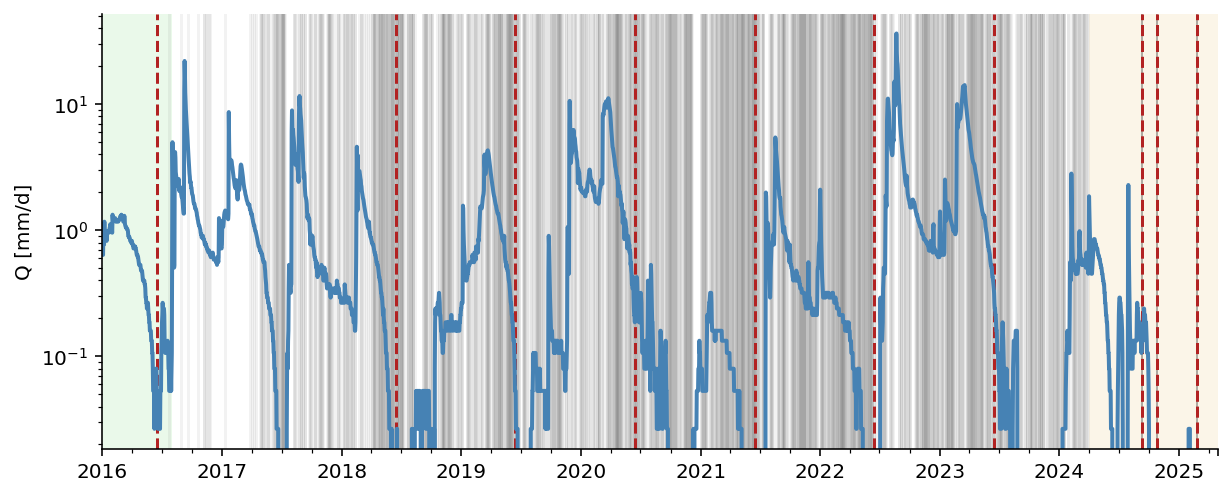

In [25]:
fig,axs = plt.subplots(1,figsize = (10,4),sharex=True)

locs = ['Ramsey',]#'Cienega']
for i,loc in enumerate(locs):
    ax = axs#[i]
    floc = '../Data/'+loc#+loc+'/'+loc
#     hydrodata = pd.read_csv(floc+'HydroData.csv',)
#     try:
#         hydrodata = hydrodata.rename(columns={'Unnamed: 0':'datetime'})
#     except:
#         continue
#     hydrodata['datetime'] = pd.to_datetime(hydrodata['datetime'])
#     hydrodata.set_index('datetime',inplace=True)
    hydrodata = df.rename(columns={'value':'Q [mm/d]'})
    hydrodata['Q [mm/d]'].plot(ax=ax,lw=2,c='steelblue',label='Q')

    imagedates = pd.read_csv(floc+'ImageryDates.csv')
    imagedates['date'] = pd.to_datetime(imagedates['date'])
    print(loc,len(imagedates))
    for j in range(len(imagedates)):
        if j==0:
            label = 'Imagery available'
        else:
            label = None
        ax.axvline(imagedates['date'].values[j],zorder=-2,alpha=.05,c='k',label = label)

    if loc=='Ramsey':
        surveyDates = [pd.to_datetime('6-15-'+str(y)) for y in range(2009,2024)]
        ndates = ['9-9-2024','10-25-2024','2-24-2025']
        surveyDates = [s for s in surveyDates if s.year!=2017]+[pd.to_datetime(d) for d in ndates]
    else:
        surveyDates = pd.read_csv(floc+'_survey_dates.csv')
        surveyDates['Cienega date'] = np.where(surveyDates['Cienega date'].isna(),
                                               surveyDates.mmddyyyy,
                                               surveyDates['Cienega date'])
        surveyDates['date'] = pd.to_datetime(surveyDates['Cienega date'])
        surveyDates = surveyDates['date'].values
    for d in ndates:
        ax.axvline(d,
                   zorder=-2,alpha=.3,c='k',label = label,lw=1)

    for j in range(len(surveyDates)):
        if j==0:
            label = 'Survey date'
        else:
            label = None
        ax.axvline(surveyDates[j],zorder = -2,c='firebrick',label=label,ls='--')
# savs 3000, vca valley 375 consult 2500-3000, ina and oracle veg veterinaey emergency group
# valley animal hospital
    
    ax.set_yscale('log')
#     ax.set_title(loc)
    ax.set_xlabel('')
    ax.set_ylabel('Q [mm/d]')
    ax.set_xlim(pd.to_datetime('1-1-2016'),
                pd.to_datetime('5-1-2025'))

#     if i==0:
#         ax.legend()
#         ax.text('2016-1-15',0.2,'a)')
#     else:
#         ax.text('2016-1-15',8,'b)')
        
for ax in [axs]:
    ax.spines[['top','right']].set_visible(False)
    
ax.axvspan(pd.to_datetime('2015-10-01'),
                pd.to_datetime('2016-8-01'),zorder = -10,facecolor = 'limegreen',
          alpha=.1)
ax.axvspan(pd.to_datetime('2024-04-01'),
                pd.to_datetime('2025-06-01'),zorder = -10,facecolor = 'goldenrod',
          alpha=.1)
        
plt.savefig('data_availability.png',format='png',dpi=300,bbox_inches='tight')

In [10]:
imagedates.drop_duplicates()

,date
0,2016-09-22
1,2016-11-17
2,2017-01-30
3,2017-02-15
4,2017-03-13
...,...
896,2024-04-07
897,2024-04-10
898,2024-04-11
899,2024-04-13
